#### Here are the Pyton tools to do curve fitting

In [8]:
import numpy as np
import matplotlib.pyplot as plt # for plot
from scipy.optimize import curve_fit # for curve fitting
from sklearn.metrics import r2_score # to calculate the R-Squared
# run this box to import the library

The S-shaped curve can be fit with this equation: $$E(T) = E_{\text{phase 2}} + \frac{E_{\text{phase 1}} - E_{\text{phase 2}}}{1 + e^{k(T - T_g)}}$$

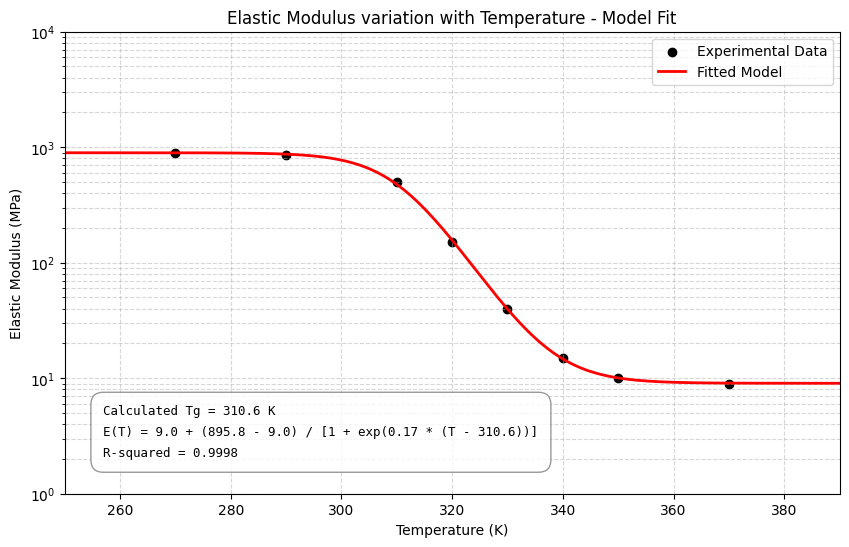

In [20]:
# 1. Define the model function
def sigmoid_model(T, E_phase_1, E_phase_2, Tg, k):
    return E_phase_2 + (E_phase_1 - E_phase_2) / (1 + np.exp(k * (T - Tg)))

# 2. Input data
temp_data = np.array([270, 290, 310, 320, 330, 340, 350, 370])
modulus_data = np.array([900, 850, 500, 150, 40, 15, 10, 9])

# 3. Perform the Curve Fit
# We fit to the LOG of the data because logarithmic display handle the display of big numbers better than linear

p0 = [1000, 10, 315, 0.2] # Initial guesses [E_glass, E_rubber, Tg, k]

# the magic the curve fitting:
params, _ = curve_fit(lambda T, Eg, Er, Tg, k: np.log10(sigmoid_model(T, Eg, Er, Tg, k)),
                      temp_data, np.log10(modulus_data), p0=p0)

# Extract fitted parameters as simple numbers
Eg_fit, Er_fit, Tg_fit, k_fit = params

# 4. Calculate R-Squared (based on log values for visual accuracy)
y_pred = sigmoid_model(temp_data, *params)
r2 = r2_score(np.log10(modulus_data), np.log10(y_pred))

# 5. Create the Plot
plt.figure(figsize=(10, 6))
plt.scatter(temp_data, modulus_data, color='black', label='Experimental Data')

t_smooth = np.linspace(250, 390, 200)
e_smooth = sigmoid_model(t_smooth, *params)
plt.plot(t_smooth, e_smooth, 'r-', linewidth=2, label='Fitted Model')

# 6. Create the Text Labels in your requested order
tg_text = f"Calculated Tg = {Tg_fit:.1f} K"
eq_text = (f"E(T) = {Er_fit:.1f} + ({Eg_fit:.1f} - {Er_fit:.1f}) / "
           f"[1 + exp({k_fit:.2f} * (T - {Tg_fit:.1f}))]")
r2_text = f"R-squared = {r2:.4f}"

# Combine into one string with newlines \n
combined_label = f"{tg_text}\n{eq_text}\n{r2_text}"

# 7. Add the Box to the Plot
plt.text(0.05, 0.08, combined_label,
         fontsize=9,
         family='monospace',
         linespacing=1.8, # Adds vertical space between lines
         transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', boxstyle='round,pad=1'))

# 8. Formatting
plt.yscale('log')
plt.ylim(1, 10000)
plt.xlim(250, 390)
plt.xlabel('Temperature (K)')
plt.ylabel('Elastic Modulus (MPa)')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(loc='upper right')
plt.title('Elastic Modulus variation with Temperature - Model Fit')

plt.show()